In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [4]:
# Load data
def load_jsonl(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl('../data/train.jsonl')
val_data = load_jsonl('../data/validation.jsonl')

print(f"Training examples: {len(train_data)}")
print(f"Validation examples: {len(val_data)}")

Training examples: 3200
Validation examples: 800


In [5]:
# Examine first example
print("\nFirst training example:")
example = train_data[0]
print(f"UUID: {example['uuid']}")
print(f"Platform: {example['postPlatform']}")
print(f"Post text: {example['postText'][0]}")
print(f"Target title: {example['targetTitle']}")
print(f"Spoiler type: {example['tags'][0]}")
print(f"Number of paragraphs: {len(example['targetParagraphs'])}")
print(f"Spoiler: {example['spoiler'][:100]}...")  # First 100 chars


First training example:
UUID: 0af11f6b-c889-4520-9372-66ba25cb7657
Platform: reddit
Post text: Wes Welker Wanted Dinner With Tom Brady, But Patriots QB Had Better Idea
Target title: Wes Welker Wanted Dinner With Tom Brady, But Patriots QB Had A Better Idea
Spoiler type: passage
Number of paragraphs: 7
Spoiler: ['how about that morning we go throw?']...


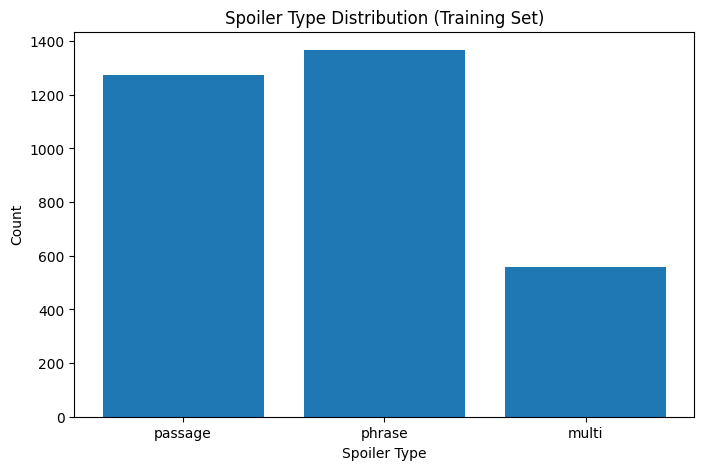


Spoiler type distribution:
passage: 1274 (39.8%)
phrase: 1367 (42.7%)
multi: 559 (17.5%)


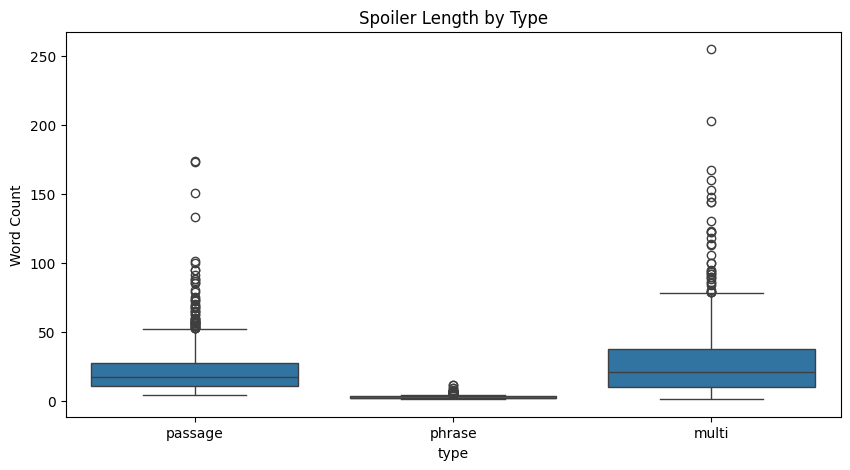


Average spoiler length by type:
          count       mean        std  min    25%   50%   75%    max
type                                                                
multi     559.0  29.118068  29.314761  1.0  10.00  21.0  37.5  255.0
passage  1274.0  21.244113  16.292570  4.0  10.25  17.0  27.0  174.0
phrase   1367.0   2.535479   1.334866  1.0   2.00   2.0   3.0   11.0

Article length statistics:
Mean: 514.8 words
Median: 352.5 words
Max: 14059 words
Min: 7 words


In [6]:
# Spoiler type distribution
spoiler_types = [ex['tags'][0] for ex in train_data]
type_counts = Counter(spoiler_types)

plt.figure(figsize=(8, 5))
plt.bar(type_counts.keys(), type_counts.values())
plt.title('Spoiler Type Distribution (Training Set)')
plt.xlabel('Spoiler Type')
plt.ylabel('Count')
plt.savefig('../results/spoiler_type_distribution.png')
plt.show()

print("\nSpoiler type distribution:")
for stype, count in type_counts.items():
    print(f"{stype}: {count} ({count/len(train_data)*100:.1f}%)")

# Spoiler length analysis
def get_spoiler_length(example):
    spoiler = example['spoiler']
    if isinstance(spoiler, list):
        spoiler = " ".join(spoiler)
    return len(spoiler.split())


spoiler_lengths = pd.DataFrame({
    'type': [ex['tags'][0] for ex in train_data],
    'length': [get_spoiler_length(ex) for ex in train_data]
})

plt.figure(figsize=(10, 5))
sns.boxplot(data=spoiler_lengths, x='type', y='length')
plt.title('Spoiler Length by Type')
plt.ylabel('Word Count')
plt.savefig('../results/spoiler_length_by_type.png')
plt.show()

print("\nAverage spoiler length by type:")
print(spoiler_lengths.groupby('type')['length'].describe())

# Article length analysis
article_lengths = [sum(len(p.split()) for p in ex['targetParagraphs']) 
                   for ex in train_data]

print(f"\nArticle length statistics:")
print(f"Mean: {np.mean(article_lengths):.1f} words")
print(f"Median: {np.median(article_lengths):.1f} words")
print(f"Max: {max(article_lengths)} words")
print(f"Min: {min(article_lengths)} words")

In [8]:
# Examine spoiler positions
example = train_data[0]
print("Spoiler positions format:")
print(f"Positions: {example['spoilerPositions']}")

# The format is: [[[paragraph_idx, start_char, end_char]]]
# For multi-part: [[[p1, s1, e1]], [[p2, s2, e2]], ...]

# Extract spoiler using positions
# def extract_spoiler_from_positions(example):
#     paragraphs = example['targetParagraphs']
#     positions = example['spoilerPositions']
#     spoiler_parts = []
    
#     for position_group in positions:
#         for para_idx, start, end in position_group:
#             text = paragraphs[para_idx][start:end]
#             spoiler_parts.append(text)
    
#     return ' '.join(spoiler_parts)

def extract_spoiler_from_positions(example):
    paragraphs = example['targetParagraphs']
    positions = example['spoilerPositions']
    spoiler_parts = []
    
    for position_group in positions:
        for pos in position_group:
            if len(pos) == 3:
                para_idx, start, end = pos
            elif len(pos) == 2:
                para_idx, start = pos
                end = len(paragraphs[para_idx])  # go until paragraph end
            else:
                raise ValueError(f"Unexpected spoiler position format: {pos}")
            
            text = paragraphs[para_idx][start:end]
            spoiler_parts.append(text)
    
    return ' '.join(spoiler_parts)


extracted = extract_spoiler_from_positions(example)
ground_truth = example['spoiler']

print(f"\nExtracted: {extracted[:100]}")
print(f"Ground truth: {ground_truth[:100]}")
print(f"Match: {extracted == ground_truth}")

Spoiler positions format:
Positions: [[[3, 151], [3, 186]]]

Extracted: how about that morning we go throw?’ " Welker said on WQAM, per The Boston Globe. "And I’m just sitt
Ground truth: ['how about that morning we go throw?']
Match: False
